### Student Name: Hilton Sarius
### Course: MAI5301 - Foundations Of Large Language Models
### Activity: Assignment #5

In [13]:
import matplotlib.pyplot as plt
import pandas as pd
import requests
import zipfile
import os

## Preparing the dataset

In [14]:
# Download zip
url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
zip_path = "spam.zip"

response = requests.get(url)
with open(zip_path, "wb") as f:
    f.write(response.content)

# Unzip
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("data")

# Rename file to .tsv
os.rename("data/SMSSpamCollection", "data/SMSSpamCollection.tsv")

print("Done. Data ready at data/SMSSpamCollection.tsv")

Done. Data ready at data/SMSSpamCollection.tsv


In [15]:
!ls -l data/

total 800
-rw-r--r-- 1 root root 162296 Mar 28 03:49 balanced_sms_spam.csv
-rw-r--r-- 1 root root   5868 Mar 28 03:50 readme
-rw-r--r-- 1 root root 477907 Mar 28 03:50 SMSSpamCollection.tsv
-rw-r--r-- 1 root root  33094 Mar 28 03:49 test.csv
-rw-r--r-- 1 root root 113645 Mar 28 03:49 train.csv
-rw-r--r-- 1 root root  15579 Mar 28 03:49 validation.csv


In [16]:
!head -n 8 data/SMSSpamCollection.tsv

ham	Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
ham	Ok lar... Joking wif u oni...
spam	Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
ham	U dun say so early hor... U c already then say...
ham	Nah I don't think he goes to usf, he lives around here though
spam	FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to send, £1.50 to rcv
ham	Even my brother is not like to speak with me. They treat me like aids patent.
ham	As per your request 'Melle Melle (Oru Minnaminunginte Nurungu Vettam)' has been set as your callertune for all Callers. Press *9 to copy your friends Callertune


Dataset shape: (5572, 2)

Class distribution:
Label
ham     4825
spam     747
Name: count, dtype: int64

Percentage:
Label
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64


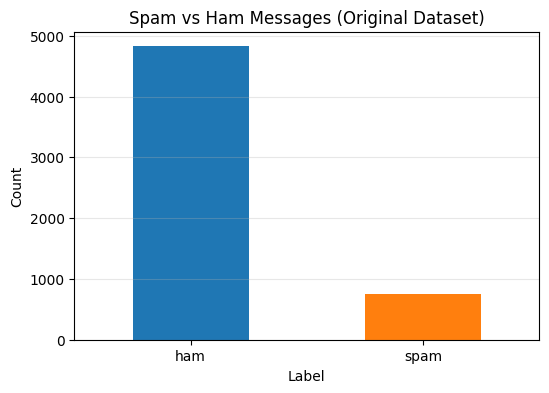

In [17]:
# Load the data
df = pd.read_csv(
    "data/SMSSpamCollection.tsv",
    sep="\t",
    header=None,
    names=["Label", "Text"]
)

# Quick overview
print("Dataset shape:", df.shape)
print("\nClass distribution:")
print(df["Label"].value_counts())
print("\nPercentage:")
print(df["Label"].value_counts(normalize=True) * 100)

# Visualize
plt.figure(figsize=(6, 4))
df["Label"].value_counts().plot(kind="bar", color=["#1f77b4", "#ff7f0e"])
plt.title("Spam vs Ham Messages (Original Dataset)")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.show()

## Creating a balanced dataset

In [18]:
# Create balanced version (equal number of ham and spam)
num_spam = df[df["Label"] == "spam"].shape[0]   # 747
ham_subset = df[df["Label"] == "ham"].sample(n=num_spam, random_state=123)

balanced_df = pd.concat([ham_subset, df[df["Label"] == "spam"]])

# Shuffle just in case
balanced_df = balanced_df.sample(frac=1, random_state=123).reset_index(drop=True)

# Map labels to 0/1 for training
balanced_df["Label"] = balanced_df["Label"].map({"ham": 0, "spam": 1})

print("Balanced dataset shape:", balanced_df.shape)
print("\nClass distribution in balanced set:")
print(balanced_df["Label"].value_counts())
print("\nFirst 5 rows of balanced_df:")
print(balanced_df.head())

# Optional: save to csv if you want to inspect later
balanced_df.to_csv("data/balanced_sms_spam.csv", index=False)
print("\nSaved balanced version → data/balanced_sms_spam.csv")

Balanced dataset shape: (1494, 2)

Class distribution in balanced set:
Label
0    747
1    747
Name: count, dtype: int64

First 5 rows of balanced_df:
   Label                                               Text
0      0                Dude how do you like the buff wind.
1      0  Tessy..pls do me a favor. Pls convey my birthd...
2      1  Reminder: You have not downloaded the content ...
3      1  Got what it takes 2 take part in the WRC Rally...
4      1  Shop till u Drop, IS IT YOU, either 10K, 5K, £...

Saved balanced version → data/balanced_sms_spam.csv


In [19]:
def random_split(df, train_frac=0.7, val_frac=0.1):
    # Shuffle the DataFrame
    df_shuffled = df.sample(frac=1, random_state=123).reset_index(drop=True)

    # Calculate split points
    n = len(df_shuffled)
    train_end = int(n * train_frac)
    val_end = train_end + int(n * val_frac)

    train_df = df_shuffled[:train_end]
    val_df   = df_shuffled[train_end:val_end]
    test_df  = df_shuffled[val_end:]

    return train_df, val_df, test_df


# Perform the split
train_df, val_df, test_df = random_split(balanced_df, train_frac=0.7, val_frac=0.1)

print(f"Train size: {len(train_df):4d} rows  ({len(train_df)/len(balanced_df):.1%})")
print(f"Val   size: {len(val_df):4d} rows  ({len(val_df)/len(balanced_df):.1%})")
print(f"Test  size: {len(test_df):4d} rows  ({len(test_df)/len(balanced_df):.1%})")

# Quick class balance check in each split
print("\nTrain class balance:\n", train_df["Label"].value_counts())
print("\nVal   class balance:\n", val_df["Label"].value_counts())
print("\nTest  class balance:\n", test_df["Label"].value_counts())

# Save to disk (in your data/ folder)
train_df.to_csv("data/train.csv", index=False)
val_df.to_csv("data/validation.csv", index=False)
test_df.to_csv("data/test.csv", index=False)

print("\nSaved:")
print("  → data/train.csv")
print("  → data/validation.csv")
print("  → data/test.csv")

Train size: 1045 rows  (69.9%)
Val   size:  149 rows  (10.0%)
Test  size:  300 rows  (20.1%)

Train class balance:
 Label
0    530
1    515
Name: count, dtype: int64

Val   class balance:
 Label
0    76
1    73
Name: count, dtype: int64

Test  class balance:
 Label
1    159
0    141
Name: count, dtype: int64

Saved:
  → data/train.csv
  → data/validation.csv
  → data/test.csv


## Creating data loaders

In [20]:
import tiktoken
import torch
from torch.utils.data import Dataset, DataLoader

In [21]:
# Get the GPT-2 tokenizer (same as used in original GPT-2)
tokenizer = tiktoken.get_encoding("gpt2")
print("Tokenizer ready. Vocab size:", tokenizer.n_vocab)

class SpamDataset(Dataset):
    def __init__(self, csv_file, tokenizer, max_length=None, pad_token_id=50256):
        self.data = pd.read_csv(csv_file)
        self.tokenizer = tokenizer
        self.pad_token_id = pad_token_id

        # Pre-tokenize all texts once (faster during training)
        self.encoded_texts = [tokenizer.encode(text) for text in self.data["Text"]]

        # Determine max_length: either user-provided or longest in dataset
        if max_length is None:
            self.max_length = self._find_longest_encoded_length()
        else:
            self.max_length = max_length
            # Truncate if longer than requested max_length
            self.encoded_texts = [enc[:self.max_length] for enc in self.encoded_texts]

        # Pad all sequences to max_length
        self.encoded_texts = [
            enc + [pad_token_id] * (self.max_length - len(enc))
            for enc in self.encoded_texts
        ]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        encoded = self.encoded_texts[idx]
        label = self.data.iloc[idx]["Label"]
        return (
            torch.tensor(encoded, dtype=torch.long),
            torch.tensor(label, dtype=torch.long)
        )

    def _find_longest_encoded_length(self):
        # Simple loop version (as in the book)
        if not self.encoded_texts:
            return 0
        return max(len(enc) for enc in self.encoded_texts)

Tokenizer ready. Vocab size: 50257


In [22]:
# Quick test: create train dataset and check its max length
train_dataset = SpamDataset(
    csv_file="data/train.csv",
    tokenizer=tokenizer,
    max_length=None   # auto-detect longest
)

print("\nTrain dataset:")
print("  Number of examples:", len(train_dataset))
print("  Max sequence length (auto-detected):", train_dataset.max_length)
print("  Example labels:", [train_dataset[i][1].item() for i in range(5)])


Train dataset:
  Number of examples: 1045
  Max sequence length (auto-detected): 120
  Example labels: [0, 1, 1, 1, 0]


In [23]:
# Re-use the max_length from train dataset
max_length = train_dataset.max_length
print(f"Using fixed max_length = {max_length} for all splits\n")

# Create datasets
val_dataset = SpamDataset(
    csv_file="data/validation.csv",
    tokenizer=tokenizer,
    max_length=max_length,
    pad_token_id=50256
)

test_dataset = SpamDataset(
    csv_file="data/test.csv",
    tokenizer=tokenizer,
    max_length=max_length,
    pad_token_id=50256
)

# DataLoaders
batch_size = 8
num_workers = 0

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    drop_last=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    drop_last=False
)

print("DataLoaders created:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val   batches: {len(val_loader)}")
print(f"  Test  batches: {len(test_loader)}")

# Quick sanity check: look at one batch from train
print("\nExample batch from train_loader:")
for input_batch, target_batch in train_loader:
    print("Input shape: ", input_batch.shape)
    print("Labels:     ", target_batch.tolist())
    break   # only show first batch

Using fixed max_length = 120 for all splits

DataLoaders created:
  Train batches: 130
  Val   batches: 19
  Test  batches: 38

Example batch from train_loader:
Input shape:  torch.Size([8, 120])
Labels:      [0, 1, 0, 0, 1, 0, 0, 1]


## Loading and modifying GPT-2 for classification

In [24]:
from gpt_download import download_and_load_gpt2
from previous_chapters import GPTModel, load_weights_into_gpt


MODEL_CHOICE = "gpt2-small (124M)"

model_configs = {
    "gpt2-small (124M)":  {"emb_dim": 768,  "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)":  {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
}

BASE_CONFIG = {
    "vocab_size": 50257,
    "context_length": 1024,
    "drop_rate": 0.0,
    "qkv_bias": True
}

BASE_CONFIG.update(model_configs[MODEL_CHOICE])

# Check that our dataset fits
assert train_dataset.max_length <= BASE_CONFIG["context_length"], \
    f"Max length {train_dataset.max_length} > model context {BASE_CONFIG['context_length']}"

print(f"Loading {MODEL_CHOICE} configuration...")

# Download weights (if not already present)
model_size = MODEL_CHOICE.split(" ")[-1].strip("()")
settings, params = download_and_load_gpt2(
    model_size=model_size,
    models_dir="gpt2_weights"
)

# Create model + load pretrained weights
model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
print("Pretrained weights loaded.")

num_classes = 2

# Replace the original language modeling head
model.out_head = torch.nn.Linear(
    in_features=BASE_CONFIG["emb_dim"],
    out_features=num_classes,
    bias=False
)

# Move to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print(f"Model moved to: {device}")
print(f"New output head shape: {model.out_head.weight.shape}")

# ── Selective freezing strategy ──────────────────────────────────────────────
# Step 1: freeze all parameters
for param in model.parameters():
    param.requires_grad = False

# Step 2: unfreeze last transformer block + final norm + classification head
for param in model.trf_blocks[-1].parameters():
    param.requires_grad = True

for param in model.final_norm.parameters():
    param.requires_grad = True

for param in model.out_head.parameters():
    param.requires_grad = True

# Count trainable parameters
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params     = sum(p.numel() for p in model.parameters())

print(f"Trainable parameters: {trainable_params:,} / {total_params:,} "
      f"({trainable_params / total_params:.2%})")


Loading gpt2-small (124M) configuration...


checkpoint: 100%|██████████| 77.0/77.0 [00:00<00:00, 49.8kiB/s]
encoder.json: 100%|██████████| 1.04M/1.04M [00:01<00:00, 952kiB/s]
hparams.json: 100%|██████████| 90.0/90.0 [00:00<00:00, 142kiB/s]
model.ckpt.data-00000-of-00001: 100%|██████████| 498M/498M [01:35<00:00, 5.20MiB/s]
model.ckpt.index: 100%|██████████| 5.21k/5.21k [00:00<00:00, 4.64MiB/s]
model.ckpt.meta: 100%|██████████| 471k/471k [00:00<00:00, 645kiB/s]
vocab.bpe: 100%|██████████| 456k/456k [00:00<00:00, 606kiB/s]


Pretrained weights loaded.
Model moved to: cuda
New output head shape: torch.Size([2, 768])
Trainable parameters: 7,090,944 / 124,441,344 (5.70%)


## Training the classifier

In [25]:
import torch.nn.functional as F
from sklearn.metrics import f1_score


def calc_accuracy_loader(data_loader, model, device, num_batches=None):
    model.eval()
    correct_predictions, num_examples = 0, 0

    if num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))

    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i >= num_batches:
            break
        input_batch  = input_batch.to(device)
        target_batch = target_batch.to(device)

        with torch.no_grad():
            logits = model(input_batch)[:, -1, :]
        predicted_labels = torch.argmax(logits, dim=-1)

        num_examples        += predicted_labels.shape[0]
        correct_predictions += (predicted_labels == target_batch).sum().item()

    return correct_predictions / num_examples


def calc_f1_loader(data_loader, model, device, num_batches=None):
    """Compute macro-averaged F1 over the loader (or first num_batches)."""
    model.eval()
    all_preds, all_labels = [], []

    if num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))

    with torch.no_grad():
        for i, (input_batch, target_batch) in enumerate(data_loader):
            if i >= num_batches:
                break
            logits = model(input_batch.to(device))[:, -1, :]
            preds  = torch.argmax(logits, dim=-1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(target_batch.numpy())

    return f1_score(all_labels, all_preds, average="macro", zero_division=0)


def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch  = input_batch.to(device)
    target_batch = target_batch.to(device)
    logits = model(input_batch)[:, -1, :]
    loss   = F.cross_entropy(logits, target_batch)
    return loss


def calc_loss_loader(data_loader, model, device, num_batches=None):
    model.eval()
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    if num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))

    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i >= num_batches:
            break
        loss = calc_loss_batch(input_batch, target_batch, model, device)
        total_loss += loss.item()

    return total_loss / num_batches


# Quick test: check initial (untrained) performance
torch.manual_seed(123)

print("Initial performance (before any training):")
train_acc = calc_accuracy_loader(train_loader, model, device, num_batches=10)
val_acc   = calc_accuracy_loader(val_loader,   model, device, num_batches=10)
test_acc  = calc_accuracy_loader(test_loader,  model, device)

print(f"  Train accuracy (first 10 batches): {train_acc:.3f}")
print(f"  Val   accuracy (first 10 batches): {val_acc:.3f}")
print(f"  Test  accuracy (full):             {test_acc:.3f}")


Initial performance (before any training):
  Train accuracy (first 10 batches): 0.550
  Val   accuracy (first 10 batches): 0.463
  Test  accuracy (full):             0.470


In [26]:
print(device)

cuda


In [27]:
import time
import torch.optim as optim


def train_classifier_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs, eval_freq, eval_iter
):
    train_losses, val_losses   = [], []
    train_accs,   val_accs     = [], []
    train_f1s,    val_f1s      = [], []
    examples_seen, global_step = 0, -1

    for epoch in range(num_epochs):
        model.train()

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()
            optimizer.step()

            examples_seen += input_batch.shape[0]
            global_step   += 1

            # Periodic loss evaluation
            if global_step % eval_freq == 0:
                train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
                val_loss   = calc_loss_loader(val_loader,   model, device, num_batches=eval_iter)
                print(f"Ep {epoch+1:02d} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f} | Val loss {val_loss:.3f}")
                train_losses.append(train_loss)
                val_losses.append(val_loss)

        # Epoch-end accuracy + F1
        train_acc = calc_accuracy_loader(train_loader, model, device, num_batches=eval_iter)
        val_acc   = calc_accuracy_loader(val_loader,   model, device, num_batches=eval_iter)
        train_f1  = calc_f1_loader(train_loader, model, device, num_batches=eval_iter)
        val_f1    = calc_f1_loader(val_loader,   model, device, num_batches=eval_iter)

        print(f"Epoch {epoch+1:02d} → "
              f"Train Acc: {train_acc:.3f} | Val Acc: {val_acc:.3f} | "
              f"Train F1: {train_f1:.3f} | Val F1: {val_f1:.3f}")

        train_accs.append(train_acc)
        val_accs.append(val_acc)
        train_f1s.append(train_f1)
        val_f1s.append(val_f1)

    return train_losses, val_losses, train_accs, val_accs, train_f1s, val_f1s, examples_seen


# Training
torch.manual_seed(123)

optimizer = optim.AdamW(
    model.parameters(),
    lr=5e-5,
    weight_decay=0.1
)

num_epochs = 5
eval_freq  = 50
eval_iter  = 5

print("Starting fine-tuning (selective freezing)...\n")

start_time = time.time()

train_losses, val_losses, train_accs, val_accs, train_f1s, val_f1s, examples_seen = \
    train_classifier_simple(
        model, train_loader, val_loader, optimizer, device,
        num_epochs=num_epochs, eval_freq=eval_freq, eval_iter=eval_iter
    )

end_time = time.time()
minutes  = (end_time - start_time) / 60

print(f"\nTraining finished in {minutes:.1f} minutes.")
print(f"Total examples processed: {examples_seen:,}")


Starting fine-tuning (selective freezing)...

Ep 01 (Step 000000): Train loss 3.139 | Val loss 3.510
Ep 01 (Step 000050): Train loss 0.627 | Val loss 0.611
Ep 01 (Step 000100): Train loss 0.429 | Val loss 0.437
Epoch 01 → Train Acc: 0.875 | Val Acc: 0.875 | Train F1: 0.925 | Val F1: 0.873
Ep 02 (Step 000150): Train loss 0.413 | Val loss 0.300
Ep 02 (Step 000200): Train loss 0.180 | Val loss 0.159
Ep 02 (Step 000250): Train loss 0.096 | Val loss 0.104
Epoch 02 → Train Acc: 0.950 | Val Acc: 0.975 | Train F1: 0.973 | Val F1: 0.975
Ep 03 (Step 000300): Train loss 0.166 | Val loss 0.091
Ep 03 (Step 000350): Train loss 0.197 | Val loss 0.059
Epoch 03 → Train Acc: 0.925 | Val Acc: 0.925 | Train F1: 0.945 | Val F1: 0.924
Ep 04 (Step 000400): Train loss 0.042 | Val loss 0.060
Ep 04 (Step 000450): Train loss 0.127 | Val loss 0.109
Ep 04 (Step 000500): Train loss 0.160 | Val loss 0.087
Epoch 04 → Train Acc: 0.975 | Val Acc: 0.975 | Train F1: 0.975 | Val F1: 0.975
Ep 05 (Step 000550): Train loss 0

In [28]:
print("Final full-dataset evaluation:")

train_acc_full = calc_accuracy_loader(train_loader, model, device)
val_acc_full   = calc_accuracy_loader(val_loader,   model, device)
test_acc_full  = calc_accuracy_loader(test_loader,  model, device)

train_f1_full  = calc_f1_loader(train_loader, model, device)
val_f1_full    = calc_f1_loader(val_loader,   model, device)
test_f1_full   = calc_f1_loader(test_loader,  model, device)

print(f"Train → Acc: {train_acc_full*100:.2f}%  F1: {train_f1_full:.4f}")
print(f"Val   → Acc: {val_acc_full*100:.2f}%  F1: {val_f1_full:.4f}")
print(f"Test  → Acc: {test_acc_full*100:.2f}%  F1: {test_f1_full:.4f}")


Final full-dataset evaluation:
Train → Acc: 97.50%  F1: 0.9759
Val   → Acc: 99.33%  F1: 0.9933
Test  → Acc: 96.00%  F1: 0.9600


## Plotting training progress (loss and accuracy)

In [29]:
import numpy as np

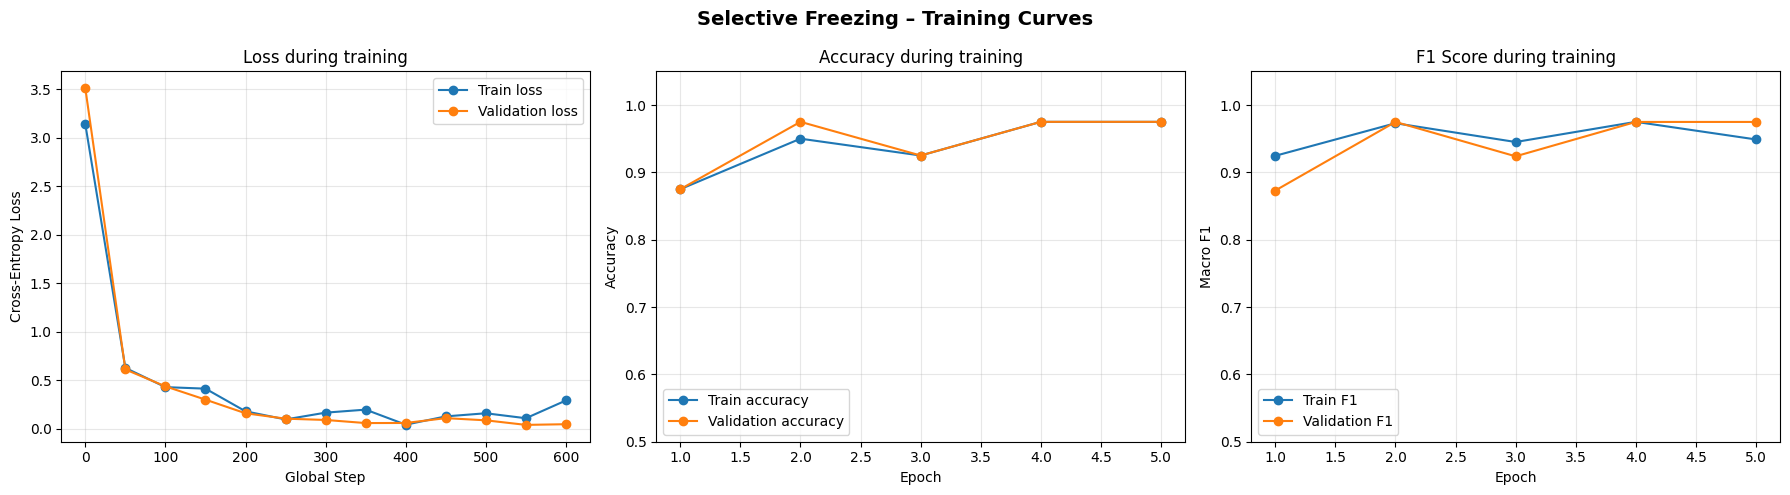

Final values:
  Last train loss: 0.2916
  Last val   loss: 0.0467
  Last train acc:  0.9750
  Last val   acc:  0.9750
  Last train F1:   0.9488
  Last val   F1:   0.9749


In [30]:
import numpy as np

epochs     = np.arange(1, len(train_accs) + 1)
loss_steps = np.arange(0, len(train_losses) * eval_freq, eval_freq)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(loss_steps, train_losses, label='Train loss',      marker='o')
axes[0].plot(loss_steps, val_losses,   label='Validation loss', marker='o')
axes[0].set_title('Loss during training')
axes[0].set_xlabel('Global Step')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(epochs, train_accs, label='Train accuracy',      marker='o')
axes[1].plot(epochs, val_accs,   label='Validation accuracy', marker='o')
axes[1].set_title('Accuracy during training')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0.5, 1.05)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# F1 score
axes[2].plot(epochs, train_f1s, label='Train F1',      marker='o')
axes[2].plot(epochs, val_f1s,   label='Validation F1', marker='o')
axes[2].set_title('F1 Score during training')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Macro F1')
axes[2].set_ylim(0.5, 1.05)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('Selective Freezing – Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Final values:")
print(f"  Last train loss: {train_losses[-1]:.4f}")
print(f"  Last val   loss: {val_losses[-1]:.4f}")
print(f"  Last train acc:  {train_accs[-1]:.4f}")
print(f"  Last val   acc:  {val_accs[-1]:.4f}")
print(f"  Last train F1:   {train_f1s[-1]:.4f}")
print(f"  Last val   F1:   {val_f1s[-1]:.4f}")


## Using the model as a spam classifier (inference)

In [31]:
# Function to classify new messages
def classify_message(
    text,
    model,
    tokenizer,
    device,
    max_length=120,
    pad_token_id=50256
):
    """
    Classify a single message as 'ham' (0) or 'spam' (1)
    """
    model.eval()

    # Tokenize and prepare input
    encoded = tokenizer.encode(text)

    # Truncate if too long
    if len(encoded) > max_length:
        encoded = encoded[:max_length]

    # Pad
    padded = encoded + [pad_token_id] * (max_length - len(encoded))

    # To tensor + batch dimension
    input_tensor = torch.tensor([padded], dtype=torch.long).to(device)

    with torch.no_grad():
        logits = model(input_tensor)[:, -1, :]   # last token logits
        predicted_class = torch.argmax(logits, dim=-1).item()

    label = "spam" if predicted_class == 1 else "ham"
    return label, predicted_class

In [32]:
# === Test on some example messages ===
examples = [
    "Win a free iPhone 15! Click here now: bit.ly/freeiphone",
    "Hey, are we still meeting at 7pm tonight?",
    "URGENT: Your account has been locked. Verify now to avoid suspension.",
    "Just checking if you received the document I sent yesterday.",
    "Congratulations! You've been selected for a $500 Amazon gift card.",
    "Can you pick up milk on your way home?",
]

print("Inference examples:\n")
for msg in examples:
    label, class_id = classify_message(
        msg,
        model,
        tokenizer,
        device,
        max_length=train_dataset.max_length
    )
    print(f"Message: {msg}")
    print(f"Prediction: {label} (class {class_id})\n")

Inference examples:

Message: Win a free iPhone 15! Click here now: bit.ly/freeiphone
Prediction: spam (class 1)

Message: Hey, are we still meeting at 7pm tonight?
Prediction: ham (class 0)

Message: URGENT: Your account has been locked. Verify now to avoid suspension.
Prediction: ham (class 0)

Message: Just checking if you received the document I sent yesterday.
Prediction: ham (class 0)

Message: Congratulations! You've been selected for a $500 Amazon gift card.
Prediction: spam (class 1)

Message: Can you pick up milk on your way home?
Prediction: ham (class 0)



## Confusion matrix & error analysis on test set

<Figure size 600x500 with 0 Axes>

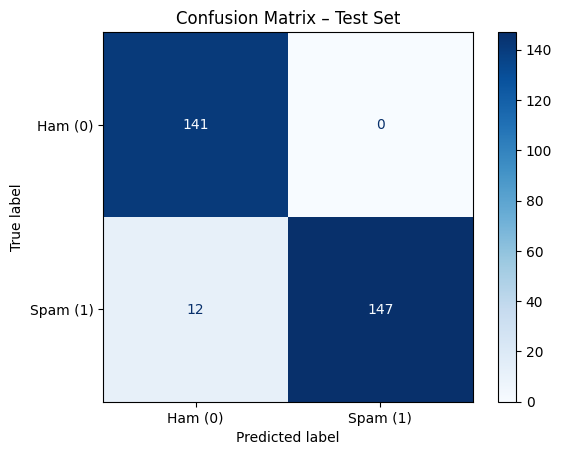

True Negative  (ham  → ham):  141
False Positive (ham  → spam): 0
False Negative (spam → ham):  12
True Positive  (spam → spam): 147

Precision (spam): 1.0000
   Recall (spam): 0.9245
       F1 (spam): 0.9608

ERROR ANALYSIS – Misclassified messages

False Positives (ham predicted as spam) — 0 cases:

False Negatives (spam predicted as ham) — 12 cases:
  [True: spam | Pred: ham] TheMob>Yo yo yo-Here comes a new selection of hot downloads for our members to get for FREE! Just click & open the next 
  [True: spam | Pred: ham] 2/2 146tf150p
  [True: spam | Pred: ham] This message is brought to you by GMW Ltd. and is not connected to the
  [True: spam | Pred: ham] For sale - arsenal dartboard. Good condition but no doubles or trebles!
  [True: spam | Pred: ham] Do you realize that in about 40 years, we'll have thousands of old ladies running around with tattoos?


In [33]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np


def get_all_predictions(loader, model, device, tokenizer=None):
    """Return predictions, true labels, and (optionally) decoded texts."""
    model.eval()
    all_preds, all_labels, all_texts = [], [], []

    with torch.no_grad():
        for input_batch, target_batch in loader:
            input_batch = input_batch.to(device)
            logits = model(input_batch)[:, -1, :]
            preds  = torch.argmax(logits, dim=-1).cpu().numpy()
            labels = target_batch.numpy()

            all_preds.extend(preds)
            all_labels.extend(labels)

            if tokenizer is not None:
                for seq in input_batch.cpu().numpy():
                    # Strip padding tokens before decoding
                    tokens = [t for t in seq if t != 50256]
                    all_texts.append(tokenizer.decode(tokens))

    return np.array(all_preds), np.array(all_labels), all_texts


# Get predictions on full test set
test_preds, test_true, test_texts = get_all_predictions(
    test_loader, model, device, tokenizer=tokenizer
)

# ── Confusion matrix ────────────────────────────────────────────────────────
cm   = confusion_matrix(test_true, test_preds, labels=[0, 1])
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Ham (0)", "Spam (1)"]
)

plt.figure(figsize=(6, 5))
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("Confusion Matrix – Test Set")
plt.grid(False)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negative  (ham  → ham):  {tn}")
print(f"False Positive (ham  → spam): {fp}")
print(f"False Negative (spam → ham):  {fn}")
print(f"True Positive  (spam → spam): {tp}")
print()
precision = tp / (tp + fp) if (tp + fp) > 0 else float('nan')
recall    = tp / (tp + fn) if (tp + fn) > 0 else float('nan')
f1        = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else float('nan')
print(f"Precision (spam): {precision:.4f}")
print(f"   Recall (spam): {recall:.4f}")
print(f"       F1 (spam): {f1:.4f}")

# ── Error analysis: show misclassified messages ──────────────────────────────
print("\n" + "="*70)
print("ERROR ANALYSIS – Misclassified messages")
print("="*70)

false_positives = [
    (test_texts[i], test_true[i], test_preds[i])
    for i in range(len(test_preds))
    if test_true[i] == 0 and test_preds[i] == 1
]

false_negatives = [
    (test_texts[i], test_true[i], test_preds[i])
    for i in range(len(test_preds))
    if test_true[i] == 1 and test_preds[i] == 0
]

print(f"\nFalse Positives (ham predicted as spam) — {len(false_positives)} cases:")
for text, true, pred in false_positives[:5]:   # show up to 5
    print(f"  [True: ham | Pred: spam] {text[:120]}")

print(f"\nFalse Negatives (spam predicted as ham) — {len(false_negatives)} cases:")
for text, true, pred in false_negatives[:5]:   # show up to 5
    print(f"  [True: spam | Pred: ham] {text[:120]}")


=== Frozen vs Full Fine-Tuning Comparison ===

Loading fresh GPT-2 small checkpoint for fair comparison...
File already exists and is up-to-date: gpt2_weights/124M/checkpoint
File already exists and is up-to-date: gpt2_weights/124M/encoder.json
File already exists and is up-to-date: gpt2_weights/124M/hparams.json
File already exists and is up-to-date: gpt2_weights/124M/model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2_weights/124M/model.ckpt.index
File already exists and is up-to-date: gpt2_weights/124M/model.ckpt.meta
File already exists and is up-to-date: gpt2_weights/124M/vocab.bpe

Training: Selective Freezing
  Trainable parameters: 7,090,944 / 124,441,344 (5.70%)
Ep 01 (Step 000000): Train loss 0.775 | Val loss 0.776
Ep 01 (Step 000050): Train loss 0.693 | Val loss 0.658
Ep 01 (Step 000100): Train loss 0.484 | Val loss 0.470
Epoch 01 → Train Acc: 0.875 | Val Acc: 0.950 | Train F1: 0.925 | Val F1: 0.950
Ep 02 (Step 000150): Train loss 0.259 | Val loss 0.17

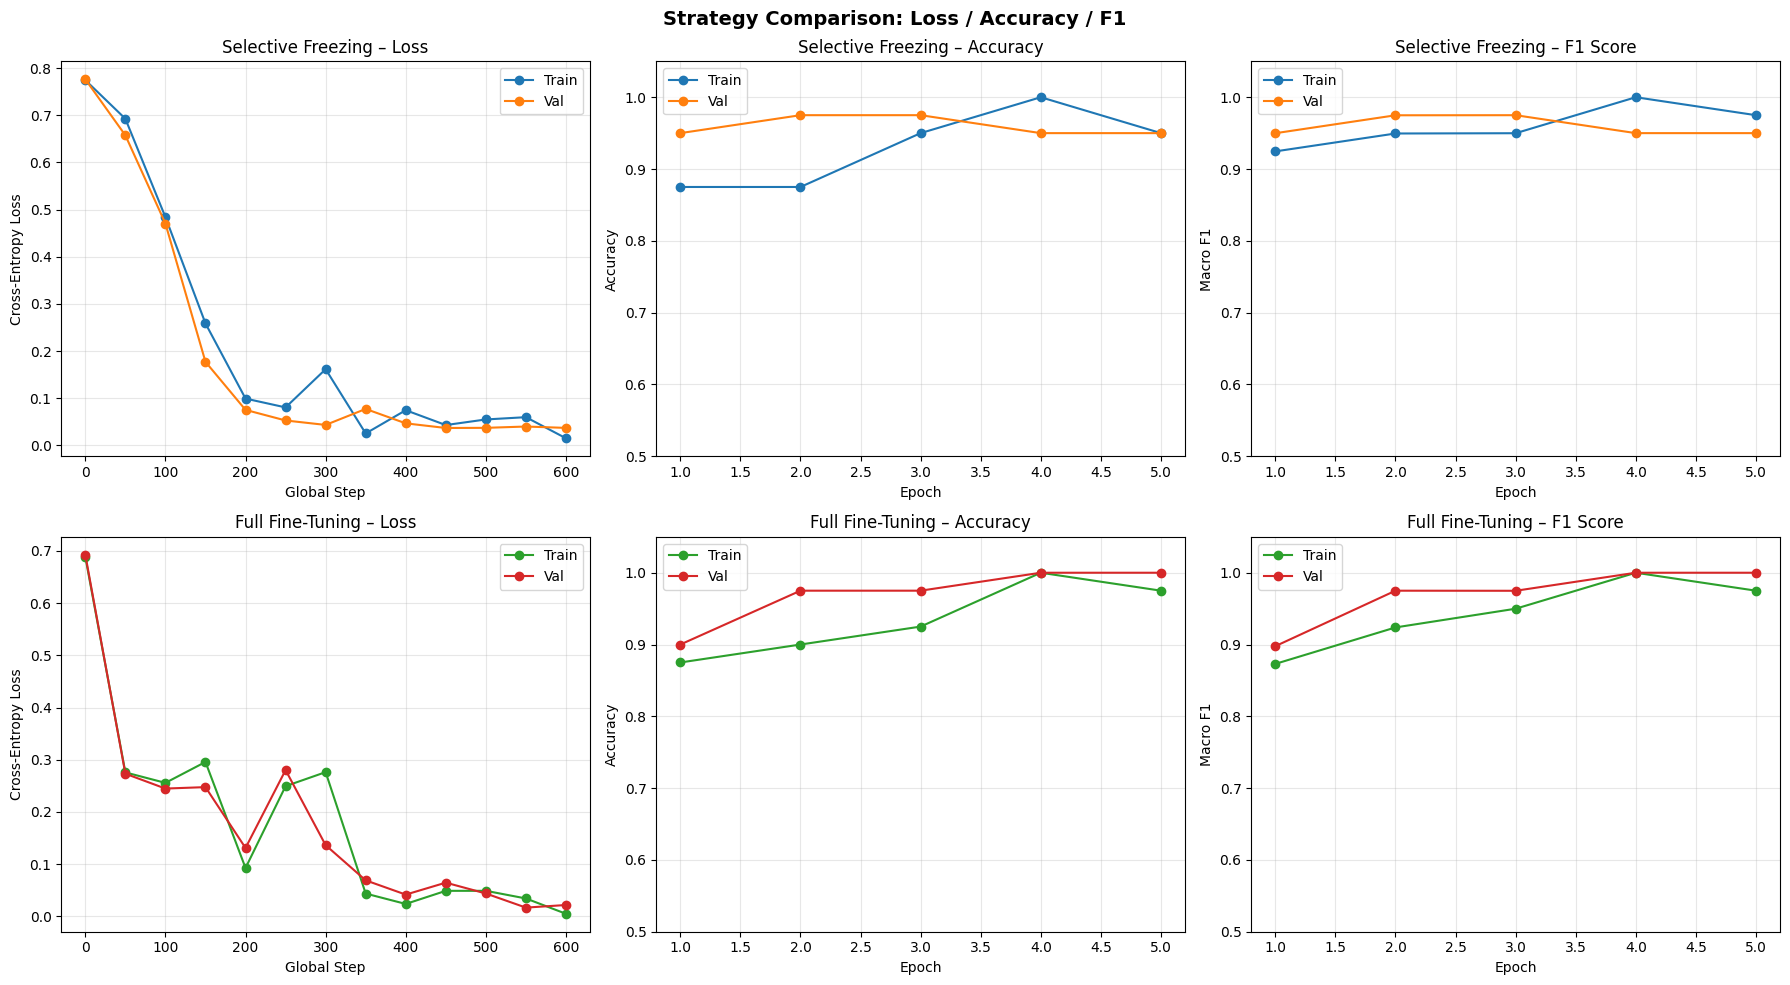


FINAL COMPARISON: Selective Freezing vs Full Fine-Tuning
--------------------------------------------------------------------------------
Approach                 Trainable Params   Test Acc   Test F1   Time (min)
--------------------------------------------------------------------------------
Selective Freezing              7,090,944     97.67%    0.9766         1.1
Full Fine-Tuning              124,441,344     96.00%    0.9600         2.8

Quick conclusion:
→ Selective freezing outperforms full fine-tuning by 1.67%.
  Likely reason: less overfitting — the frozen backbone acts as a regulariser.


In [34]:
print("=== Frozen vs Full Fine-Tuning Comparison ===\n")

# Shared setup – reload fresh pretrained base model
print("Loading fresh GPT-2 small checkpoint for fair comparison...")

MODEL_CHOICE = "gpt2-small (124M)"

model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
}
BASE_CONFIG = {
    "vocab_size": 50257,
    "context_length": 1024,
    "drop_rate": 0.0,
    "qkv_bias": True
}
BASE_CONFIG.update(model_configs[MODEL_CHOICE])

model_size = MODEL_CHOICE.split(" ")[-1].strip("()")
_, params  = download_and_load_gpt2(model_size=model_size, models_dir="gpt2_weights")


# ── Helper to build a fresh model with chosen freezing strategy ──────────────
def build_model(params, freeze_strategy):
    """Return a model with the requested freezing strategy applied.
    freeze_strategy: 'selective' | 'full'
    """
    m = GPTModel(BASE_CONFIG)
    load_weights_into_gpt(m, params)
    m.out_head = torch.nn.Linear(BASE_CONFIG["emb_dim"], 2, bias=False)
    m.to(device)

    if freeze_strategy == "selective":
        for param in m.parameters():
            param.requires_grad = False
        # Unfreeze last block + norm + head
        for param in m.trf_blocks[-1].parameters():
            param.requires_grad = True
        for param in m.final_norm.parameters():
            param.requires_grad = True
        for param in m.out_head.parameters():
            param.requires_grad = True
    else:  # 'full'
        for param in m.parameters():
            param.requires_grad = True

    return m


results = {}

for strategy, lr in [("selective", 5e-5), ("full", 1e-5)]:
    label = "Selective Freezing" if strategy == "selective" else "Full Fine-Tuning"
    print(f"\n{'='*50}")
    print(f"Training: {label}")
    print(f"{'='*50}")

    torch.manual_seed(123)

    m   = build_model(params, strategy)
    opt = optim.AdamW(m.parameters(), lr=lr, weight_decay=0.1)

    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in m.parameters())
    print(f"  Trainable parameters: {trainable:,} / {total:,} ({trainable/total:.2%})")

    t0 = time.time()
    tr_losses, va_losses, tr_accs, va_accs, tr_f1s, va_f1s, _ = \
        train_classifier_simple(
            m, train_loader, val_loader, opt, device,
            num_epochs=5, eval_freq=50, eval_iter=5
        )
    elapsed = (time.time() - t0) / 60

    test_acc = calc_accuracy_loader(test_loader, m, device)
    test_f1  = calc_f1_loader(test_loader, m, device)

    print(f"  → Finished in {elapsed:.1f} minutes")
    print(f"  Test Acc: {test_acc*100:.2f}%  |  Test F1: {test_f1:.4f}")

    torch.save(m.state_dict(), f"spam_classifier_{strategy}.pth")
    print(f"  Saved: spam_classifier_{strategy}.pth")

    results[label] = {
        "trainable": trainable, "total": total,
        "time_min": elapsed,
        "test_acc": test_acc, "test_f1": test_f1,
        "tr_losses": tr_losses, "va_losses": va_losses,
        "tr_accs": tr_accs, "va_accs": va_accs,
        "tr_f1s": tr_f1s, "va_f1s": va_f1s,
    }


# ── Side-by-side training curves ─────────────────────────────────────────────
import numpy as np

epochs     = np.arange(1, 6)
loss_steps = np.arange(0, len(results["Selective Freezing"]["tr_losses"]) * 50, 50)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
strategies = ["Selective Freezing", "Full Fine-Tuning"]
colors     = [("#1f77b4", "#ff7f0e"), ("#2ca02c", "#d62728")]

for row, (strat, (c_train, c_val)) in enumerate(zip(strategies, colors)):
    r = results[strat]

    axes[row, 0].plot(loss_steps, r["tr_losses"], color=c_train, marker='o', label='Train')
    axes[row, 0].plot(loss_steps, r["va_losses"], color=c_val,   marker='o', label='Val')
    axes[row, 0].set_title(f"{strat} – Loss")
    axes[row, 0].set_xlabel("Global Step")
    axes[row, 0].set_ylabel("Cross-Entropy Loss")
    axes[row, 0].legend(); axes[row, 0].grid(True, alpha=0.3)

    axes[row, 1].plot(epochs, r["tr_accs"], color=c_train, marker='o', label='Train')
    axes[row, 1].plot(epochs, r["va_accs"], color=c_val,   marker='o', label='Val')
    axes[row, 1].set_title(f"{strat} – Accuracy")
    axes[row, 1].set_xlabel("Epoch")
    axes[row, 1].set_ylabel("Accuracy")
    axes[row, 1].set_ylim(0.5, 1.05)
    axes[row, 1].legend(); axes[row, 1].grid(True, alpha=0.3)

    axes[row, 2].plot(epochs, r["tr_f1s"], color=c_train, marker='o', label='Train')
    axes[row, 2].plot(epochs, r["va_f1s"], color=c_val,   marker='o', label='Val')
    axes[row, 2].set_title(f"{strat} – F1 Score")
    axes[row, 2].set_xlabel("Epoch")
    axes[row, 2].set_ylabel("Macro F1")
    axes[row, 2].set_ylim(0.5, 1.05)
    axes[row, 2].legend(); axes[row, 2].grid(True, alpha=0.3)

plt.suptitle("Strategy Comparison: Loss / Accuracy / F1", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


# ── Final summary table ───────────────────────────────────────────────────────
print("\n" + "="*80)
print("FINAL COMPARISON: Selective Freezing vs Full Fine-Tuning")
print("-"*80)
print(f"{'Approach':<22} {'Trainable Params':>18} {'Test Acc':>10} {'Test F1':>9} {'Time (min)':>12}")
print("-"*80)
for strat in strategies:
    r = results[strat]
    print(f"{strat:<22} {r['trainable']:>18,} {r['test_acc']*100:>9.2f}% {r['test_f1']:>9.4f} {r['time_min']:>11.1f}")
print("="*80)

print("\nQuick conclusion:")
acc_delta = results["Full Fine-Tuning"]["test_acc"] - results["Selective Freezing"]["test_acc"]

if acc_delta > 0.01:
    print(f"→ Full fine-tuning outperforms selective freezing by {acc_delta*100:.2f}%.")
    print("  Trade-off: longer training time and higher risk of overfitting on small datasets.")
elif acc_delta < -0.01:
    print(f"→ Selective freezing outperforms full fine-tuning by {abs(acc_delta)*100:.2f}%.")
    print("  Likely reason: less overfitting — the frozen backbone acts as a regulariser.")
else:
    print(f"→ Performance is nearly identical (Δ {acc_delta*100:.2f}%).")
    print("  Selective freezing is the pragmatic choice: fewer trainable params, faster training,")
    print("  lower memory footprint, and reduced overfitting risk.")
